## Walmart Recruiting - Store Sales Forecasting — ARIMA / SARIMA

**ARIMA** (AutoRegressive Integrated Moving Average) და მისი სეზონური გაფართოება
**SARIMA** კლასიკური სტატისტიკური დროითი მწკრივის მოდელებია. განსხვავებით NBEATS/TFT
-ის მსგავსი deep-learning არქიტექტურებისგან, რომლებიც **ერთ გლობალურ მოდელს**
სწავლობენ ყველა (Store, Dept) სერიაზე ერთდროულად (shared weights), ARIMA/SARIMA
**თითოეულ დროით მწკრივს ცალ-ცალკე, დამოუკიდებლად** ეყრდნობა — თითოეული
`unique_id`-სთვის ცალკე მოდელი ფასდება, საკუთარი კოეფიციენტებით. მოდელი აგებულია
სამი კომპონენტისგან: **AR(p)** (მწკრივის საკუთარ წარსულ მნიშვნელობებზე რეგრესია),
**I(d)** (დიფერენცირება არასტაციონარულობის მოსაცილებლად) და **MA(q)** (წარსულ
prediction-შეცდომებზე რეგრესია). **SARIMA**-ს ემატება სეზონური `(P, D, Q, s)`
კომპონენტი — ჩვენს შემთხვევაში `s=52` (კვირეული მონაცემი, წლიური სეზონურობა).

დავალების ინსტრუქციის თანახმად (*"ARIMA/SARIMA ძველი მოდელებია და უფრო
მნიშვნელოვანია თეორიულად გარჩევა, მათ ტრენინგზე დიდი დრო არ დახარჯოთ"*), ეს
notebook ორიენტირებულია **მეთოდოლოგიურ სისწორეზე და ჰიპერპარამეტრების
სისტემურ შედარებაზე**, და არა უზარმაზარ compute-ბიუჯეტზე — HP search
ტარდება მცირე, წარმომადგენლობით სერიების სემფლზე (არა deep-learning
მოდელების მსგავსად ასეულ სერიაზე), რადგან თითოეული კონფიგურაცია მოითხოვს
**ცალკე fit-ს თითო სერიაზე** (არა ერთ საერთო fit-ს, როგორც NBEATS/TFT-ში).

**სტრუქტურა** იმეორებს NBEATS/TFT notebook-ების სტრუქტურას პირდაპირი
შედარებისთვის: Setup → Data Cleaning → Feature Engineering → Feature
Selection (**ინფორმაციული მხოლოდ** — საბაზისო ARIMA/SARIMA არ იღებს გარე
ცვლადებს) → Train/Validation split + WMAE → სტაციონარულობის შემოწმება
(ADF + ACF/PACF) → **HP Search Stage 1 (Random Search)** → **HP Search
Stage 2 (Full Factorial Grid Search, დინამიურად დაზუსტებული Stage 1-ის
შედეგებზე დაყრდნობით)** → Final Training → Deploy Refit + Pipeline +
Model Registry (fallback-ით) → Visualizations → Full Text Summary.

**ჰიპერპარამეტრები**, რომლებიც სისტემურად ტესტდება ამ notebook-ში: `p` (AR
წესრიგი), `d` (დიფერენცირების ხარისხი), `q` (MA წესრიგი). ეს **წმინდა ARIMA**
notebook-ია — სეზონური კომპონენტი აქ არასდროს ირთვება (`seasonal_order=(0,0,0,0)`
ფიქსირებული). სეზონური SARIMA ცალკე notebook-შია გატესტილი
(`model_experiment_SARIMA.ipynb`), იმავე HP-search სტრუქტურით, მაგრამ
`seasonal_order=(1,1,1,52)` ფიქსირებულით.

## 0. Setup

In [1]:
!pip install -q statsmodels wandb

In [2]:
import os
import glob
import time
import pickle
import random
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

import wandb

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

MODEL_NAME = "ARIMA"
WANDB_PROJECT = "walmart-sales-forecasting"

def _find_data_dir():
    candidates = glob.glob("/kaggle/input/**/train.csv*", recursive=True)
    if candidates:
        return os.path.dirname(candidates[0])
    return "./data"

DATA_DIR = _find_data_dir()
print("DATA_DIR:", DATA_DIR)
print("ნაპოვნი ფაილები:", os.listdir(DATA_DIR) if os.path.isdir(DATA_DIR) else "(საქაღალდე არ არსებობს)")

FIGURES_DIR = "./arima_figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

HORIZON = 39
SEASONAL_PERIOD = 52

wandb.login()

DATA_DIR: /kaggle/input/competitions/walmart-recruiting-store-sales-forecasting
ნაპოვნი ფაილები: ['train.csv.zip', 'sampleSubmission.csv.zip', 'stores.csv', 'features.csv.zip', 'test.csv.zip']


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: sgurj22 (TwoMusketeers) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## 1. Data Cleaning
ჩატვირთვა, merge (`stores`/`features`), დუბლიკატების მოცილება, MarkDown NA->0,
CPI/Unemployment forward/back-fill თითო Store-ისთვის, უარყოფითი გაყიდვების ჭრა 0-ზე.
იდენტურია NBEATS/TFT notebook-ების ლოგიკის — ეს ეტაპი მოდელის არქიტექტურისგან
დამოუკიდებელია.

In [3]:
train_raw = pd.read_csv(glob.glob(f"{DATA_DIR}/train.csv*")[0], parse_dates=["Date"])
test_raw = pd.read_csv(glob.glob(f"{DATA_DIR}/test.csv*")[0], parse_dates=["Date"])
stores = pd.read_csv(glob.glob(f"{DATA_DIR}/stores.csv*")[0])
features = pd.read_csv(glob.glob(f"{DATA_DIR}/features.csv*")[0], parse_dates=["Date"])

def merge_sources(df):
    feat = features.drop(columns=["IsHoliday"])
    return df.merge(stores, on="Store", how="left").merge(feat, on=["Store", "Date"], how="left")

def clean_data(df, is_train=True):
    df = df.copy()
    n_before = len(df)
    df = df.drop_duplicates()

    markdown_cols = [c for c in df.columns if c.startswith("MarkDown")]
    markdown_na = int(df[markdown_cols].isna().sum().sum())
    df[markdown_cols] = df[markdown_cols].fillna(0).clip(lower=0)

    df = df.sort_values(["Store", "Date"])
    for col in ["CPI", "Unemployment"]:
        df[col] = df.groupby("Store")[col].ffill().bfill()

    neg_count = 0
    if is_train:
        neg_count = int((df["Weekly_Sales"] < 0).sum())
        df["Weekly_Sales"] = df["Weekly_Sales"].clip(lower=0)

    df["IsHoliday"] = df["IsHoliday"].astype(bool)
    df["Store"] = df["Store"].astype(int)
    df["Dept"] = df["Dept"].astype(int)

    stats = {"rows_before": n_before, "rows_after": len(df),
              "duplicates_removed": n_before - len(df),
              "negative_sales_clipped": neg_count, "markdown_na_filled": markdown_na}
    return df, stats

train_clean, train_stats = clean_data(merge_sources(train_raw), is_train=True)
test_clean, test_stats = clean_data(merge_sources(test_raw), is_train=False)
print("train:", train_clean.shape, train_stats)
print("test:", test_clean.shape, test_stats)

train: (421570, 16) {'rows_before': 421570, 'rows_after': 421570, 'duplicates_removed': 0, 'negative_sales_clipped': 1285, 'markdown_na_filled': 1422431}
test: (115064, 15) {'rows_before': 115064, 'rows_after': 115064, 'duplicates_removed': 0, 'negative_sales_clipped': 0, 'markdown_na_filled': 51493}


In [4]:
run = wandb.init(project=WANDB_PROJECT, group=MODEL_NAME, job_type="cleaning", name=f"{MODEL_NAME}_Cleaning")
wandb.config.update({f"train_{k}": v for k, v in train_stats.items()})
wandb.config.update({f"test_{k}": v for k, v in test_stats.items()})
wandb.log({"train_missing_after_clean": int(train_clean.isna().sum().sum()),
           "test_missing_after_clean": int(test_clean.isna().sum().sum())})
run.finish()

test_missing_after_clean,▁
train_missing_after_clean,▁
test_missing_after_clean,0
train_missing_after_clean,0


## 2. Feature Engineering
ARIMA/SARIMA **univariate** მოდელია — ცალკეული სერიის `y`-ს გარდა სხვა ცვლადებს
input-ად არ იღებს (base-line SARIMAX ტექნიკურად exog-საც უჭერს მხარს, მაგრამ ეს
notebook-ის scope-ს სცდება, დავალების ინსტრუქციის თანახმად). ამიტომ ეს სექცია
მხოლოდ საჭირო მინიმუმს აგებს: კალენდარული ველები (`IsHoliday` და Kaggle-ის
"special" holiday კვირები, WMAE-ს წონისთვის საჭირო) და `unique_id`/`ds`/`y`.

In [5]:
def add_calendar_flags(df):
    df = df.copy()
    df["Year"] = df["Date"].dt.year
    df["Month"] = df["Date"].dt.month
    df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)

    superbowl = pd.to_datetime(["2010-02-12", "2011-02-11", "2012-02-10", "2013-02-08"])
    labor_day = pd.to_datetime(["2010-09-10", "2011-09-09", "2012-09-07", "2013-09-06"])
    thanksgiving = pd.to_datetime(["2010-11-26", "2011-11-25", "2012-11-23", "2013-11-29"])
    christmas = pd.to_datetime(["2010-12-31", "2011-12-30", "2012-12-28", "2013-12-27"])
    df["IsSuperBowl"] = df["Date"].isin(superbowl)
    df["IsLaborDay"] = df["Date"].isin(labor_day)
    df["IsThanksgiving"] = df["Date"].isin(thanksgiving)
    df["IsChristmas"] = df["Date"].isin(christmas)
    return df

def engineer_features(df):
    df = add_calendar_flags(df)
    df["unique_id"] = df["Store"].astype(str) + "_" + df["Dept"].astype(str)
    df["ds"] = df["Date"]
    return df

train_fe = engineer_features(train_clean)
train_fe["y"] = train_fe["Weekly_Sales"]
test_fe = engineer_features(test_clean)
print(train_fe.shape, "| unique series:", train_fe["unique_id"].nunique())

(421570, 26) | unique series: 3331


In [6]:
run = wandb.init(project=WANDB_PROJECT, group=MODEL_NAME, job_type="feature_engineering", name=f"{MODEL_NAME}_FeatureEngineering")
wandb.log({"n_unique_series": train_fe["unique_id"].nunique(), "n_rows_train": len(train_fe)})
run.finish()

n_rows_train,▁
n_unique_series,▁
n_rows_train,421570
n_unique_series,3331


## 3. Feature Selection (ინფორმაციული მხოლოდ)

TFT-სგან განსხვავებით (სადაც selection რეალურად განსაზღვრავდა `futr_exog_list`-ს),
ბაზისური ARIMA/SARIMA **ვერ იღებს** გარე (exogenous) ცვლადებს — ეს სექცია აქ,
NBEATS notebook-ის მსგავსად, **მხოლოდ საინფორმაციოა**: გვიჩვენებს რომელ გარე
ცვლადებს აქვს ყველაზე ძლიერი კავშირი `y`-სთან, README-ისთვის და მომავალი
გაფართოებისთვის (SARIMAX `exog=`), თუმცა ეს notebook დავალების ინსტრუქციის
თანახმად (*"ARIMA/SARIMA-ს ტრენინგზე დიდი დრო არ დახარჯოთ"*) ამ გაფართოებას
სცილდება და მკაცრად univariate რჩება.

In [7]:
candidate_exog = ["Temperature", "Fuel_Price", "CPI", "Unemployment",
                   "MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]

corr = train_fe[candidate_exog + ["y"]].corr()["y"].drop("y").abs()
missing_rate = train_fe[candidate_exog].isna().mean()
selection_table = pd.DataFrame({"abs_corr_with_y": corr, "missing_rate": missing_rate}) \
    .sort_values("abs_corr_with_y", ascending=False)

print("(ინფორმაციული -- ARIMA/SARIMA ამ notebook-ში ამ ცვლადებს არ იყენებს)")
selection_table

(ინფორმაციული -- ARIMA/SARIMA ამ notebook-ში ამ ცვლადებს არ იყენებს)


,abs_corr_with_y,missing_rate
MarkDown5,0.050465,0.0
MarkDown1,0.047172,0.0
MarkDown3,0.038562,0.0
MarkDown4,0.037467,0.0
Unemployment,0.025860,0.0
CPI,0.020923,0.0
MarkDown2,0.020720,0.0
Temperature,0.002312,0.0
Fuel_Price,0.000121,0.0


In [8]:
run = wandb.init(project=WANDB_PROJECT, group=MODEL_NAME, job_type="feature_selection", name=f"{MODEL_NAME}_FeatureSelection")
wandb.config.update({"note": "informational only -- base ARIMA/SARIMA is univariate, no exog used"})
run.finish()

## 4. Train / Validation Split + WMAE

Test set 39 კვირით მომავალშია, ამიტომ validation-ადაც ბოლო **39 კვირას** ვჭრით
(იგივე ლოგიკა, რაც NBEATS/TFT notebook-ებში — Kaggle leaderboard-ის რეალური
იმიტაცია). დამატებით ARIMA/SARIMA-ს, deep-learning მოდელებისგან განსხვავებით
(რომლებსაც `start_padding_enabled` შეუძლიათ ხარვეზების ავსება), სჭირდება
**მთლიანად უწყვეტი, გაუწყვეტელი (weekly, `freq='W-FRI'`) history** თითო
სერიაზე — წინააღმდეგ შემთხვევაში სეზონური lag-ები (`s=52`) არასწორად
გასწორდება. ამიტომ HP search/deployment-ში მონაწილეობს მხოლოდ ის სერიები,
რომლებსაც აქვთ (ა) საკმარისი ისტორია (>= 2*HORIZON კვირა), (ბ) სრული,
ხარვეზების გარეშე validation-window და (გ) სრული, ხარვეზების გარეშე
train-window.

In [9]:
arima_cols = ["unique_id", "ds", "y", "IsHoliday"]
arima_df = train_fe[arima_cols].dropna(subset=["y"]).sort_values(["unique_id", "ds"]).reset_index(drop=True)

cutoff_date = arima_df["ds"].max() - pd.Timedelta(weeks=HORIZON)
Y_train = arima_df[arima_df["ds"] <= cutoff_date].copy()
Y_valid = arima_df[arima_df["ds"] > cutoff_date].copy()

counts = Y_train.groupby("unique_id").size()
valid_ids = set(Y_valid["unique_id"]) & set(Y_train["unique_id"])
valid_ids = [uid for uid in valid_ids if counts.get(uid, 0) >= 2 * HORIZON]

expected_valid_dates = set(pd.date_range(
    start=cutoff_date + pd.Timedelta(weeks=1), end=arima_df["ds"].max(), freq="W-FRI"
))
valid_date_sets = Y_valid.groupby("unique_id")["ds"].apply(set)
n_before_valid_filter = len(valid_ids)
valid_ids = [uid for uid in valid_ids if valid_date_sets.get(uid, set()) == expected_valid_dates]
print(f"არასრული validation calendar coverage-ის გამო გამოირიცხა: "
      f"{n_before_valid_filter - len(valid_ids)} სერია (დარჩა: {len(valid_ids)})")

train_date_sets = Y_train.groupby("unique_id")["ds"].apply(set)
def _is_continuous(uid):
    dates = train_date_sets.get(uid, set())
    if not dates:
        return False
    full_range = set(pd.date_range(start=min(dates), end=cutoff_date, freq="W-FRI"))
    return dates == full_range

n_before_gap_filter = len(valid_ids)
valid_ids = [uid for uid in valid_ids if _is_continuous(uid)]
print(f"გაწყვეტილი (non-continuous) train-history-ის გამო გამოირიცხა: "
      f"{n_before_gap_filter - len(valid_ids)} სერია (დარჩა: {len(valid_ids)})")

Y_train = Y_train[Y_train["unique_id"].isin(valid_ids)].reset_index(drop=True)
Y_valid = Y_valid[Y_valid["unique_id"].isin(valid_ids)].reset_index(drop=True)
arima_df = arima_df[arima_df["unique_id"].isin(valid_ids)].reset_index(drop=True)
print(f"cutoff={cutoff_date.date()} | series={len(valid_ids)} | train rows={len(Y_train)} | valid rows={len(Y_valid)}")

def wmae(y_true, y_pred, is_holiday):
    w = np.where(np.asarray(is_holiday).astype(bool), 5, 1)
    return float(np.sum(w * np.abs(np.asarray(y_true) - np.asarray(y_pred))) / np.sum(w))

არასრული validation calendar coverage-ის გამო გამოირიცხა: 131 სერია (დარჩა: 2727)
გაწყვეტილი (non-continuous) train-history-ის გამო გამოირიცხა: 57 სერია (დარჩა: 2670)
cutoff=2012-01-27 | series=2670 | train rows=277574 | valid rows=104130


## 4b. სტაციონარულობის შემოწმება (ADF) + ACF/PACF

ARIMA/SARIMA-ს ორდერების (`p`, `d`, `q`, სეზონურობა) გაცნობიერებული არჩევანისთვის
პირველი ნაბიჯი ყოველთვის სტაციონარულობის შემოწმებაა. ვიღებთ ყველა სერიის ჯამურ
(აგრეგირებულ) კვირეულ გაყიდვებს — წარმომადგენლობითი "მაკრო" სურათისთვის — და
ვატარებთ **Augmented Dickey-Fuller (ADF)** ტესტს დონეზე და პირველ სხვაობაზე
(`d=1`), შემდეგ ვხატავთ **ACF/PACF** გრაფიკებს დიფერენცირებულ მწკრივზე, რაც
პირდაპირ ხელმძღვანელობს `p`/`q`/სეზონური ორდერების საძიებო სივრცის არჩევას
ქვემოთ, HP search-ის სექციაში.

ADF (level):      statistic=-4.8814 | p-value=0.0000
ADF (diff, d=1):  statistic=-5.4276 | p-value=0.0000
შენიშვნა: სემფლი (103 დაკვირვება) საკმარისი არ არის სრული 52-lag ACF/PACF-სთვის -- ვიყენებთ 50 lag-ს ამის ნაცვლად.


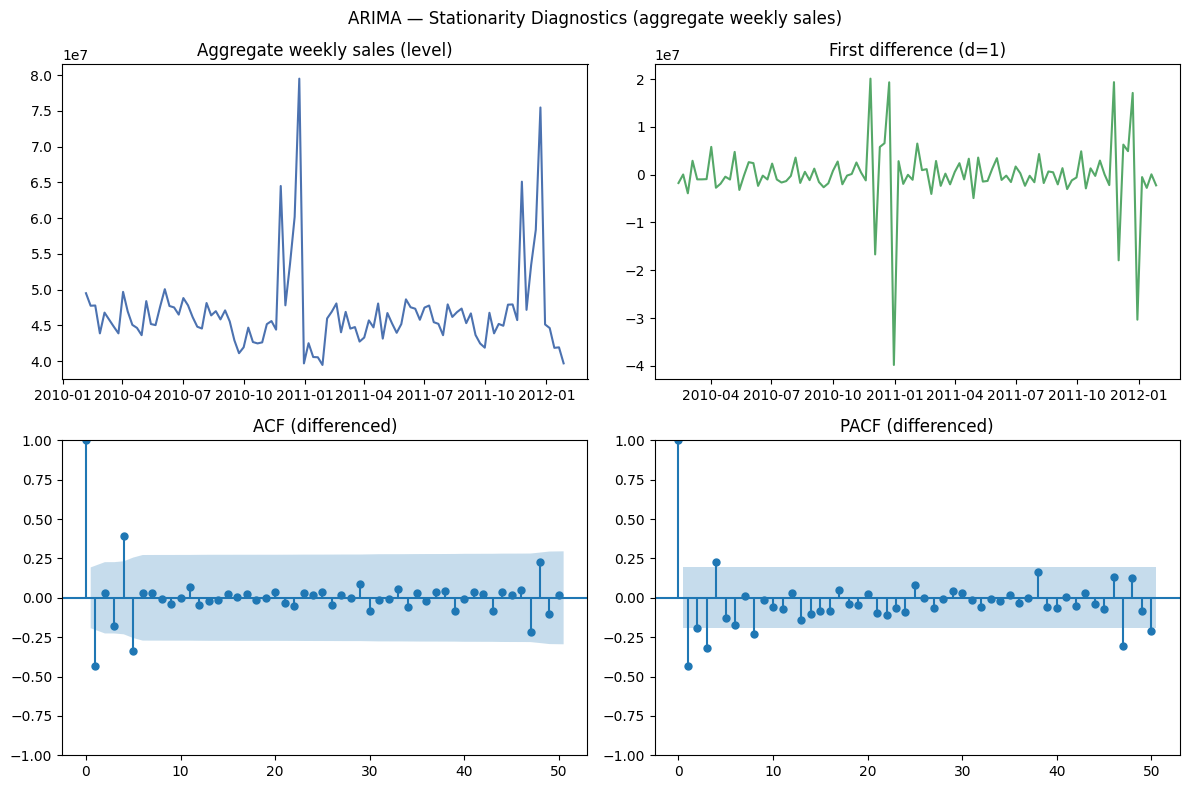

In [10]:
agg_series = Y_train.groupby("ds")["y"].sum().sort_index()
agg_series.index = pd.DatetimeIndex(agg_series.index, freq="W-FRI")

adf_level = adfuller(agg_series)
adf_diff = adfuller(agg_series.diff().dropna())
print(f"ADF (level):      statistic={adf_level[0]:.4f} | p-value={adf_level[1]:.4f}")
print(f"ADF (diff, d=1):  statistic={adf_diff[0]:.4f} | p-value={adf_diff[1]:.4f}")

diff_series = agg_series.diff().dropna()
max_safe_lags = max(1, diff_series.shape[0] // 2 - 1)
acf_pacf_lags = min(SEASONAL_PERIOD, max_safe_lags)
if acf_pacf_lags < SEASONAL_PERIOD:
    print(f"შენიშვნა: სემფლი ({diff_series.shape[0]} დაკვირვება) საკმარისი არ არის სრული "
          f"{SEASONAL_PERIOD}-lag ACF/PACF-სთვის -- ვიყენებთ {acf_pacf_lags} lag-ს ამის ნაცვლად.")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].plot(agg_series.index, agg_series.values, color="#4C72B0")
axes[0, 0].set_title("Aggregate weekly sales (level)")
axes[0, 1].plot(diff_series, color="#55A868")
axes[0, 1].set_title("First difference (d=1)")
plot_acf(diff_series, ax=axes[1, 0], lags=acf_pacf_lags)
axes[1, 0].set_title("ACF (differenced)")
plot_pacf(diff_series, ax=axes[1, 1], lags=acf_pacf_lags, method="ywm")
axes[1, 1].set_title("PACF (differenced)")
fig.suptitle("ARIMA — Stationarity Diagnostics (aggregate weekly sales)")
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/arima_stationarity_acf_pacf.png", dpi=150)
plt.show()

run = wandb.init(project=WANDB_PROJECT, group=MODEL_NAME, job_type="diagnostics", name=f"{MODEL_NAME}_Stationarity")
wandb.config.update({"adf_level_pvalue": float(adf_level[1]), "adf_diff_pvalue": float(adf_diff[1]),
                      "acf_pacf_lags_used": acf_pacf_lags})
wandb.log({"stationarity_acf_pacf": wandb.Image(f"{FIGURES_DIR}/arima_stationarity_acf_pacf.png")})
run.finish()

## 5. Hyperparameter Search — Stage 1 (Random Search)

NBEATS/TFT-ის მსგავსად, `search_space`-დან შემთხვევით ვსემფლავთ `N_TRIALS`
უნიკალურ კონფიგურაციას. ეს არის **წმინდა ARIMA** notebook — სეზონური კომპონენტი
აქ არასდროს ირთვება (`seasonal_order=(0,0,0,0)` ყოველთვის); სეზონური SARIMA
ცალკე notebook-შია გატესტილი (`model_experiment_SARIMA.ipynb`), იმავე HP-search
სტრუქტურით. სისტემურად ტესტდება `p`, `d`, `q`. Score არის სემფლის ყველა სერიაზე
ერთდროულად აგრეგირებული (concatenated) WMAE, ისევე როგორც TFT-ში.

In [11]:
HP_SEARCH_SAMPLE_N = 15

rng_ids = np.random.RandomState(RANDOM_SEED)
sample_ids = sorted(rng_ids.choice(sorted(valid_ids), size=min(HP_SEARCH_SAMPLE_N, len(valid_ids)), replace=False))
Y_train_sample = Y_train[Y_train["unique_id"].isin(sample_ids)].reset_index(drop=True)
Y_valid_sample = Y_valid[Y_valid["unique_id"].isin(sample_ids)].reset_index(drop=True)
print("HP-search series:", len(sample_ids))

search_space = {
    "p": [0, 1, 2],
    "d": [0, 1],
    "q": [0, 1, 2],
}
total_combos = int(np.prod([len(v) for v in search_space.values()]))
rng = random.Random(RANDOM_SEED)
N_TRIALS = 8
configs = []
seen = set()
while len(configs) < N_TRIALS:
    cfg = {k: rng.choice(v) for k, v in search_space.items()}
    key = tuple(sorted(cfg.items()))
    if key not in seen:
        seen.add(key)
        configs.append(cfg)
print(f"{len(configs)} random configs to test (სრული სივრცე: {total_combos} კომბინაცია).")

HP-search series: 15
8 random configs to test (სრული სივრცე: 18 კომბინაცია).


In [12]:
def build_order(cfg):
    order = (cfg["p"], cfg["d"], cfg["q"])
    seasonal_order = (0, 0, 0, 0)
    return order, seasonal_order

def fit_forecast_one(y_hist: pd.Series, order, seasonal_order, steps):
    try:
        model = SARIMAX(y_hist, order=order, seasonal_order=seasonal_order,
                         enforce_stationarity=False, enforce_invertibility=False)
        res = model.fit(disp=False, maxiter=50)
        fc = res.get_forecast(steps=steps).predicted_mean.values

        max_reasonable = max(float(y_hist.max()), 1.0) * 20
        if not np.all(np.isfinite(fc)) or np.any(np.abs(fc) > max_reasonable):
            raise ValueError("Forecast exploded / non-finite -- treating fit as failed.")

        fc = np.clip(fc, 0, None)
        return fc, True
    except Exception:
        if len(y_hist) >= SEASONAL_PERIOD:
            base = y_hist.values[-SEASONAL_PERIOD:]
            reps = int(np.ceil(steps / SEASONAL_PERIOD))
            fc = np.tile(base, reps)[:steps]
        else:
            fc = np.full(steps, y_hist.values[-1])
        return fc, False

def evaluate_config(cfg, train_df, valid_df, ids):
    order, seasonal_order = build_order(cfg)
    all_preds = []
    n_failed = 0
    for uid in ids:
        y_hist = train_df[train_df["unique_id"] == uid].set_index("ds")["y"]
        y_hist.index = pd.DatetimeIndex(y_hist.index, freq="W-FRI")
        dates_needed = valid_df[valid_df["unique_id"] == uid].sort_values("ds")["ds"].tolist()
        steps = len(dates_needed)
        if steps == 0:
            continue
        fc, ok = fit_forecast_one(y_hist, order, seasonal_order, steps)
        if not ok:
            n_failed += 1
        all_preds.append(pd.DataFrame({"unique_id": uid, "ds": dates_needed, "y_pred": fc}))

    preds = pd.concat(all_preds, ignore_index=True) if all_preds else pd.DataFrame(columns=["unique_id", "ds", "y_pred"])
    merged = preds.merge(valid_df[["unique_id", "ds", "y", "IsHoliday"]], on=["unique_id", "ds"], how="inner")
    if merged.empty:
        return np.inf, np.inf, n_failed, merged
    score = wmae(merged["y"], merged["y_pred"], merged["IsHoliday"])
    mae = float(np.mean(np.abs(merged["y"] - merged["y_pred"])))
    return score, mae, n_failed, merged

In [13]:
results = []
for i, cfg in enumerate(configs):
    trial_label = f"trial{i}"
    print(f"\n=== {MODEL_NAME}_HPSearch_{trial_label} {cfg} ===")
    t0 = time.time()
    run = wandb.init(project=WANDB_PROJECT, group=MODEL_NAME, job_type="hp_search",
                      name=f"{MODEL_NAME}_HPSearch_{trial_label}", config=cfg, reinit=True)

    score, mae, n_failed, _ = evaluate_config(cfg, Y_train_sample, Y_valid_sample, sample_ids)
    elapsed_min = (time.time() - t0) / 60

    wandb.log({"val_WMAE": score, "val_MAE": mae, "n_failed_fits": n_failed, "train_minutes": elapsed_min})
    run.finish()
    results.append({**cfg, "trial": trial_label, "val_WMAE": score, "val_MAE": mae,
                     "n_failed_fits": n_failed, "train_minutes": elapsed_min})
    print(f"WMAE={score:.2f} | MAE={mae:.2f} | failed={n_failed}/{len(sample_ids)} | {elapsed_min:.1f} min")

results_df = pd.DataFrame(results).sort_values("val_WMAE")
n_failed_all = int(np.isinf(results_df["val_WMAE"]).sum())
if n_failed_all:
    print(f"WARNING: {n_failed_all}/{len(results_df)} trials failed evaluation (val_WMAE=inf) -- check errors above.")

best_row = results_df.iloc[0]
best_cfg = {k: (best_row[k].item() if hasattr(best_row[k], "item") else best_row[k]) for k in search_space}
print("\nStage 1 საუკეთესო კონფიგურაცია:", best_row["trial"], dict(best_cfg))
results_df


=== ARIMA_HPSearch_trial0 {'p': 2, 'd': 0, 'q': 0} ===


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


n_failed_fits,▁
train_minutes,▁
val_MAE,▁
val_WMAE,▁
n_failed_fits,0
train_minutes,0.11434
val_MAE,4301.72007
val_WMAE,4405.91646


WMAE=4405.92 | MAE=4301.72 | failed=0/15 | 0.1 min

=== ARIMA_HPSearch_trial1 {'p': 2, 'd': 1, 'q': 0} ===


n_failed_fits,▁
train_minutes,▁
val_MAE,▁
val_WMAE,▁
n_failed_fits,0
train_minutes,0.10861
val_MAE,2464.93214
val_WMAE,2615.38108


...

n_failed_fits,▁
train_minutes,▁
val_MAE,▁
val_WMAE,▁
n_failed_fits,0
train_minutes,0.11352
val_MAE,2617.17829
val_WMAE,2776.11946


WMAE=2776.12 | MAE=2617.18 | failed=0/15 | 0.1 min

=== ARIMA_HPSearch_trial7 {'p': 1, 'd': 1, 'q': 0} ===


n_failed_fits,▁
train_minutes,▁
val_MAE,▁
val_WMAE,▁
n_failed_fits,0
train_minutes,0.10966
val_MAE,2475.29635
val_WMAE,2633.85493


WMAE=2633.85 | MAE=2475.30 | failed=0/15 | 0.1 min

Stage 1 საუკეთესო კონფიგურაცია: trial1 {'p': 2, 'd': 1, 'q': 0}


,p,d,q,trial,val_WMAE,val_MAE,n_failed_fits,train_minutes
1,2,1,0,trial1,2615.381077,2464.932143,0,0.108611
7,1,1,0,trial7,2633.854926,2475.296349,0,0.109661
6,0,1,0,trial6,2776.119461,2617.178291,0,0.113519
5,2,0,2,trial5,2846.137584,2750.531841,0,0.138675
0,2,0,0,trial0,4405.916459,4301.720073,0,0.114343
3,1,0,0,trial3,5583.467183,5516.364184,0,0.113191
2,0,0,2,trial2,13010.701786,13049.939525,0,0.122177
4,0,0,0,trial4,13508.995745,13336.929846,0,0.110228


## 5b. Hyperparameter Search — Stage 2 (Full Factorial Grid Search)

`d`-ს კანდიდატი **დინამიურად** ვიწროვდება Stage 1-ის საუკეთესო შედეგზე დაყრდნობით
(იგივე მიდგომა, რაც TFT-ის Stage 2-ში `input_size`-თან), ხოლო `p`/`q` დიაპაზონი
ოდნავ ფართოვდება (`+1` ზედა ზღვარზე), რომ Stage 1-ის საზღვართან ახლოს ყოფილიყო
ოპტიმუმი, დამატებით შემოწმდეს.

In [14]:
best_d = int(results_df.sort_values("val_WMAE").iloc[0]["d"])
print("Stage 2 -- fixed d (dynamic, Stage 1 best):", best_d)

search_space_2 = {
    "p": [0, 1, 2, 3],
    "d": [best_d],
    "q": [0, 1, 2, 3],
}

keys, values = zip(*search_space_2.items())
configs_2 = [dict(zip(keys, combo)) for combo in itertools.product(*values)]
print(f"{len(configs_2)} grid configs to test (Stage 2 -- full factorial).")

Stage 2 -- fixed d (dynamic, Stage 1 best): 1
16 grid configs to test (Stage 2 -- full factorial).


In [15]:
results_2 = []
for i, cfg in enumerate(configs_2):
    trial_label = f"trial{i}"
    print(f"\n=== {MODEL_NAME}_HPSearch2_{trial_label} {cfg} ===")
    t0 = time.time()
    run = wandb.init(project=WANDB_PROJECT, group=MODEL_NAME, job_type="hp_search_2",
                      name=f"{MODEL_NAME}_HPSearch2_{trial_label}", config=cfg, reinit=True)

    score, mae, n_failed, _ = evaluate_config(cfg, Y_train_sample, Y_valid_sample, sample_ids)
    elapsed_min = (time.time() - t0) / 60

    wandb.log({"val_WMAE": score, "val_MAE": mae, "n_failed_fits": n_failed, "train_minutes": elapsed_min})
    run.finish()
    results_2.append({**cfg, "trial": trial_label, "val_WMAE": score, "val_MAE": mae,
                       "n_failed_fits": n_failed, "train_minutes": elapsed_min})
    print(f"WMAE={score:.2f} | MAE={mae:.2f} | failed={n_failed}/{len(sample_ids)} | {elapsed_min:.1f} min")

results_2_df = pd.DataFrame(results_2).sort_values("val_WMAE")
n_failed_2 = int(np.isinf(results_2_df["val_WMAE"]).sum())
if n_failed_2:
    print(f"WARNING: {n_failed_2}/{len(results_2_df)} trials failed evaluation (val_WMAE=inf) -- check errors above.")

best_row_2 = results_2_df.iloc[0]
best_cfg_2 = {k: (best_row_2[k].item() if hasattr(best_row_2[k], "item") else best_row_2[k]) for k in search_space_2}
print("\nStage 2 საუკეთესო კონფიგურაცია:", best_row_2["trial"], dict(best_cfg_2))
results_2_df


=== ARIMA_HPSearch2_trial0 {'p': 0, 'd': 1, 'q': 0} ===


n_failed_fits,▁
train_minutes,▁
val_MAE,▁
val_WMAE,▁
n_failed_fits,0
train_minutes,0.11091
val_MAE,2617.17829
val_WMAE,2776.11946


WMAE=2776.12 | MAE=2617.18 | failed=0/15 | 0.1 min

=== ARIMA_HPSearch2_trial1 {'p': 0, 'd': 1, 'q': 1} ===


n_failed_fits,▁
train_minutes,▁
val_MAE,▁
val_WMAE,▁
n_failed_fits,0
train_minutes,0.11489
val_MAE,2603.40655
val_WMAE,2690.71069


WMAE=2690.71 | MAE=2603.41 | failed=0/15 | 0.1 min

=== ARIMA_HPSearch2_trial2 {'p': 0, 'd': 1, 'q': 2} ===


...

WMAE=2712.11 | MAE=2661.22 | failed=0/15 | 0.1 min

=== ARIMA_HPSearch2_trial15 {'p': 3, 'd': 1, 'q': 3} ===


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


n_failed_fits,▁
train_minutes,▁
val_MAE,▁
val_WMAE,▁
n_failed_fits,0
train_minutes,0.15542
val_MAE,2468.75298
val_WMAE,2558.75407


WMAE=2558.75 | MAE=2468.75 | failed=0/15 | 0.2 min

Stage 2 საუკეთესო კონფიგურაცია: trial10 {'p': 2, 'd': 1, 'q': 2}


,p,d,q,trial,val_WMAE,val_MAE,n_failed_fits,train_minutes
10,2,1,2,trial10,2448.831299,2359.716931,0,0.131035
9,2,1,1,trial9,2505.636076,2448.238369,0,0.128791
12,3,1,0,trial12,2531.311005,2405.847161,0,0.109250
13,3,1,1,trial13,2555.056365,2455.388704,0,0.125971
11,2,1,3,trial11,2557.349809,2492.300897,0,0.139362
15,3,1,3,trial15,2558.754066,2468.752977,0,0.155418
8,2,1,0,trial8,2615.381077,2464.932143,0,0.110587
4,1,1,0,trial4,2633.854926,2475.296349,0,0.113429
2,0,1,2,trial2,2663.518180,2592.236000,0,0.117693
6,1,1,2,trial6,2677.686243,2568.891734,0,0.127528


In [16]:
if best_row_2["val_WMAE"] < best_row["val_WMAE"]:
    winning_stage = "stage_2 (full grid)"
    best_cfg = best_cfg_2
    best_val_wmae = float(best_row_2["val_WMAE"])
else:
    winning_stage = "stage_1 (random search)"
    best_val_wmae = float(best_row["val_WMAE"])

print(f"გამარჯვებული: {winning_stage}")
print(f"საბოლოო best_cfg: {best_cfg}")
print(f"საბოლოო HP-search val_WMAE ({len(sample_ids)}-series sample): {best_val_wmae:.2f}")
print(f"შედარებისთვის -- stage1 best: {best_row['val_WMAE']:.2f} | stage2 best: {best_row_2['val_WMAE']:.2f}")

გამარჯვებული: stage_2 (full grid)
საბოლოო best_cfg: {'p': 2, 'd': 1, 'q': 2}
საბოლოო HP-search val_WMAE (15-series sample): 2448.83
შედარებისთვის -- stage1 best: 2615.38 | stage2 best: 2448.83


## 6. Final Training

საბოლოო, ორივე HP-search ეტაპიდან გამარჯვებული `(p,d,q)`-თი ვაფასებთ
**ბევრად უფრო ფართო** სერიების ნაკრებზე (`Y_train` -> `Y_valid`, 39-კვირიანი
holdout, არასოდეს ნანახი HP-search-ში). ვინაიდან თითოეული სერია ცალკე fit-ს
მოითხოვს (განსხვავებით NBEATS/TFT-ის ერთი გლობალური fit-ისგან), გამოთვლითი
დროის გონივრულ ფარგლებში დასაჭერად (დავალების ინსტრუქციის თანახმად) საბოლოო
შეფასების სერიების რაოდენობა შემოსაზღვრულია `MAX_FINAL_SERIES`-ით — თუ
`valid_ids`-ის რაოდენობა მეტია, ვსემფლავთ შემთხვევით ქვესიმრავლეს.

In [17]:
MAX_FINAL_SERIES = 300
if len(valid_ids) > MAX_FINAL_SERIES:
    rng_final = np.random.RandomState(RANDOM_SEED)
    final_eval_ids = sorted(rng_final.choice(sorted(valid_ids), size=MAX_FINAL_SERIES, replace=False))
    print(f"შენიშვნა: საბოლოო შეფასების სემფლი დაზუსტებულია {MAX_FINAL_SERIES} სერიამდე "
          f"({len(valid_ids)}-დან) გამოთვლითი დროის დაზოგვის მიზნით (დავალების მითითების "
          f"თანახმად, ARIMA/SARIMA-ს ტრენინგზე ბევრი დრო არ უნდა დაიხარჯოს).")
else:
    final_eval_ids = sorted(valid_ids)

run = wandb.init(project=WANDB_PROJECT, group=MODEL_NAME, job_type="final",
                  name=f"{MODEL_NAME}_Final_Training", config=dict(best_cfg))
wandb.config.update({"winning_hp_search_stage": winning_stage, "n_final_eval_series": len(final_eval_ids)})

t0 = time.time()
final_order, final_seasonal_order = build_order(best_cfg)
final_wmae, final_mae, final_failed, final_merged = evaluate_config(best_cfg, Y_train, Y_valid, final_eval_ids)
elapsed_min = (time.time() - t0) / 60

wandb.log({"val_WMAE": final_wmae, "val_MAE": final_mae, "n_failed_fits": final_failed, "train_minutes": elapsed_min})
run.finish()

print(f"{MODEL_NAME} final WMAE={final_wmae:.2f} | MAE={final_mae:.2f} | "
      f"failed={final_failed}/{len(final_eval_ids)} | {elapsed_min:.1f} min")

შენიშვნა: საბოლოო შეფასების სემფლი დაზუსტებულია 300 სერიამდე (2670-დან) გამოთვლითი დროის დაზოგვის მიზნით (დავალების მითითების თანახმად, ARIMA/SARIMA-ს ტრენინგზე ბევრი დრო არ უნდა დაიხარჯოს).


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


n_failed_fits,▁
train_minutes,▁
val_MAE,▁
val_WMAE,▁
n_failed_fits,0
train_minutes,0.80389
val_MAE,3044.67419
val_WMAE,3038.53684


ARIMA final WMAE=3038.54 | MAE=3044.67 | failed=0/300 | 0.8 min


## 7. Deploy Refit + Pipeline + Model Registry

`final_order`/`final_seasonal_order` ცნობილია — ახლა თითოეულ სერიაზე ვაფიტებთ
**მთელ ხელმისაწვდომ ისტორიაზე** (`arima_df`, train+valid, ბოლო თარიღი
2012-10-26), რომ test-პერიოდის (2012-11-02 -> 2013-07-26) 39-კვირიანი
prognoz-ი დავაგენერიროთ. ვინაიდან NeuralForecast-ის `nf.save()`-ის მსგავსი
ჩაშენებული serialization statsmodels-ს არ გააჩნია, თითოეული სერიის fit-ული
`SARIMAXResults` ობიექტი **pickle**-ით ინახება ერთ დირექტორიაში
(`PIPELINE_DIR`), როგორც `{unique_id: SARIMAXResults}` dict. `ARIMAPipeline`
კლასი (analog: `TFTPipeline`) იმეორებს raw dataframe -> clean_data ->
engineer_features -> per-series `get_forecast()` -> **fallback**
(Store/Dept/global საშუალო) ლოგიკას, უცნობი ან ჩავარდნილი fit-ის მქონე
სერიებისთვის.

In [18]:
run = wandb.init(project=WANDB_PROJECT, group=MODEL_NAME, job_type="deploy_refit",
                  name=f"{MODEL_NAME}_Deploy_Refit", config=dict(best_cfg))

t0 = time.time()
deploy_ids = sorted(arima_df["unique_id"].unique())
fitted_models = {}
deploy_failed = 0
for j, uid in enumerate(deploy_ids):
    y_hist = arima_df[arima_df["unique_id"] == uid].set_index("ds")["y"]
    y_hist.index = pd.DatetimeIndex(y_hist.index, freq="W-FRI")
    try:
        model = SARIMAX(y_hist, order=final_order, seasonal_order=final_seasonal_order,
                         enforce_stationarity=False, enforce_invertibility=False)
        fitted_models[uid] = model.fit(disp=False, maxiter=50)
    except Exception:
        fitted_models[uid] = None
        deploy_failed += 1
    if (j + 1) % 500 == 0:
        print(f"  fitted {j + 1}/{len(deploy_ids)} series...")

elapsed_min = (time.time() - t0) / 60
deploy_max_date = arima_df["ds"].max()
wandb.log({"train_minutes": elapsed_min, "n_series_fitted": len(deploy_ids), "n_deploy_fit_failed": deploy_failed})
wandb.config.update({"deploy_max_train_date": str(deploy_max_date.date())})

PIPELINE_DIR = "./arima_pipeline_model"
os.makedirs(PIPELINE_DIR, exist_ok=True)
with open(f"{PIPELINE_DIR}/fitted_models.pkl", "wb") as f:
    pickle.dump({"order": final_order, "seasonal_order": final_seasonal_order,
                 "models": fitted_models, "last_date": deploy_max_date}, f)
run.finish()
print(f"Deploy refit done ({elapsed_min:.1f} min) | failed fits: {deploy_failed}/{len(deploy_ids)} "
      f"| pipeline saved to: {PIPELINE_DIR}")

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  fitted 500/2670 series...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  fitted 1000/2670 series...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

...

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

  fitted 2500/2670 series...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

n_deploy_fit_failed,▁
n_series_fitted,▁
train_minutes,▁
n_deploy_fit_failed,0
n_series_fitted,2670
train_minutes,7.80196


Deploy refit done (7.8 min) | failed fits: 0/2670 | pipeline saved to: ./arima_pipeline_model


In [19]:
class ARIMAPipeline:

    def __init__(self, fitted_models, last_date, history_df):
        self.fitted_models = fitted_models
        self.last_date = last_date
        self._dept_mean = history_df.groupby(["Store", "Dept"])["y"].mean()
        self._store_mean = history_df.groupby("Store")["y"].mean()
        self._global_mean = float(history_df["y"].mean())

    def _fallback_value(self, store, dept):
        key = (store, dept)
        if key in self._dept_mean.index:
            return float(self._dept_mean[key])
        if store in self._store_mean.index:
            return float(self._store_mean[store])
        return self._global_mean

    def predict(self, raw_df: pd.DataFrame) -> pd.DataFrame:
        df = raw_df.copy()
        df["Date"] = pd.to_datetime(df["Date"])
        df, _ = clean_data(merge_sources(df), is_train=False)
        df = engineer_features(df)

        out_rows = []
        for uid, g in df.groupby("unique_id"):
            store, dept = int(g["Store"].iloc[0]), int(g["Dept"].iloc[0])
            dates = g.sort_values("ds")["ds"].tolist()
            steps = max((max(dates) - self.last_date).days // 7, 0)
            res = self.fitted_models.get(uid)

            preds = [np.nan] * len(dates)
            if res is not None and steps > 0:
                try:
                    fc = res.get_forecast(steps=steps).predicted_mean
                    fc_vals = fc.values
                    hist_max = float(g["y"].max()) if "y" in g.columns and g["y"].notna().any() else np.nan
                    max_reasonable = max(hist_max, 1.0) * 20 if np.isfinite(hist_max) else np.inf
                    fc_vals = np.where(
                        np.isfinite(fc_vals) & (np.abs(fc_vals) <= max_reasonable),
                        np.clip(fc_vals, 0, None), np.nan
                    )
                    future_dates = pd.date_range(self.last_date + pd.Timedelta(weeks=1), periods=steps, freq="W-FRI")
                    fc_map = dict(zip(future_dates, fc_vals))
                    preds = [fc_map.get(d, np.nan) for d in dates]
                except Exception:
                    pass

            out_rows.append(pd.DataFrame({"unique_id": uid, "ds": dates, "Store": store, "Dept": dept,
                                           "Weekly_Sales_Pred": preds}))

        out = pd.concat(out_rows, ignore_index=True)
        missing = out["Weekly_Sales_Pred"].isna()
        n_missing = int(missing.sum())
        if n_missing:
            out.loc[missing, "Weekly_Sales_Pred"] = out.loc[missing].apply(
                lambda r: self._fallback_value(r["Store"], r["Dept"]), axis=1
            )
            print(f"ARIMAPipeline: filled {n_missing}/{len(out)} rows "
                  f"({n_missing / len(out):.1%}) via Store/Dept fallback mean.")

        return out.drop(columns=["Store", "Dept"])

pipeline = ARIMAPipeline(fitted_models, last_date=deploy_max_date, history_df=train_fe)

preds_preview = pipeline.predict(test_raw)
print("Output Shape:", preds_preview.shape)
preds_preview.head(10)

ARIMAPipeline: filled 11022/115064 rows (9.6%) via Store/Dept fallback mean.
Output Shape: (115064, 3)


,unique_id,ds,Weekly_Sales_Pred
0,10_1,2012-11-02,49922.051424
1,10_1,2012-11-09,39940.196012
2,10_1,2012-11-16,39056.901142
3,10_1,2012-11-23,37840.561055
4,10_1,2012-11-30,37751.543808
5,10_1,2012-12-07,37603.022046
6,10_1,2012-12-14,37594.475311
7,10_1,2012-12-21,37576.302001
8,10_1,2012-12-28,37575.545421
9,10_1,2013-01-04,37573.316982


In [20]:
run = wandb.init(project=WANDB_PROJECT, group=MODEL_NAME, job_type="registry",
                  name=f"{MODEL_NAME}_Pipeline_Registry")

artifact = wandb.Artifact(name=f"{MODEL_NAME}_pipeline", type="model",
                           metadata={**dict(best_cfg), "order": str(final_order), "seasonal_order": str(final_seasonal_order)})
artifact.add_dir(PIPELINE_DIR)
run.log_artifact(artifact)
run.link_artifact(artifact, target_path=f"wandb-registry-model/{MODEL_NAME}")
run.finish()
print(f"'{MODEL_NAME}_pipeline' დარეგისტრირდა Wandb Registry-ში.")

wandb: Adding directory to artifact (arima_pipeline_model)... Done. 4.2s


'ARIMA_pipeline' დარეგისტრირდა Wandb Registry-ში.


## 8. შედეგების ვიზუალიზაცია (README-სთვის)

5 გრაფიკი, PNG-ად შენახული ლოკალურად `./arima_figures/`-ში **და** wandb-ზე
ატვირთული (`wandb.Image`): (1) სტაციონარულობის ADF/ACF/PACF დიაგნოსტიკა
(უკვე შენახულია §4b-ში), (2) exogenous corr-table (ინფორმაციული), (3) Stage 1
(random search) და (4) Stage 2 (grid search) HP-შედეგები, (5) Actual vs
Predicted სემფლ სერიებზე, (6) Predicted vs Actual scatter (calibration).

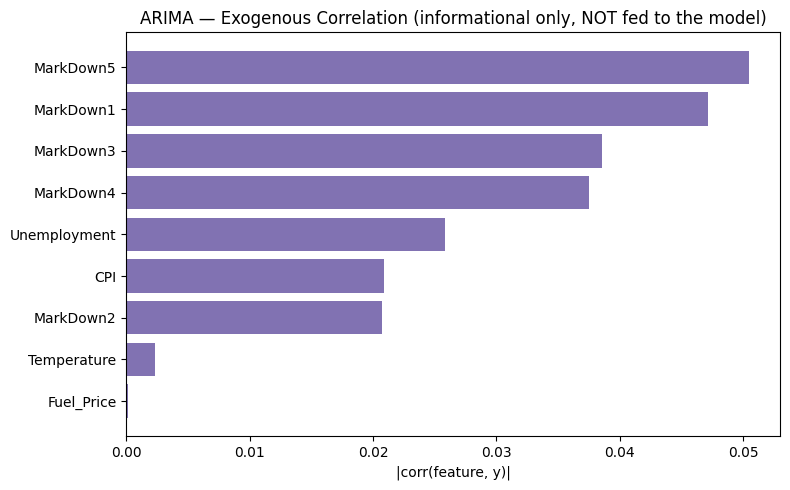

In [21]:
sel_sorted = selection_table.sort_values("abs_corr_with_y")
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(sel_sorted.index, sel_sorted["abs_corr_with_y"], color="#8172B2")
ax.set_xlabel("|corr(feature, y)|")
ax.set_title("ARIMA — Exogenous Correlation (informational only, NOT fed to the model)")
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/arima_feature_correlation.png", dpi=150)
plt.show()

run = wandb.init(project=WANDB_PROJECT, group=MODEL_NAME, job_type="visualization",
                  name=f"{MODEL_NAME}_Viz_FeatureCorrelation", reinit=True)
wandb.log({"feature_correlation": wandb.Image(f"{FIGURES_DIR}/arima_feature_correlation.png")})
run.finish()

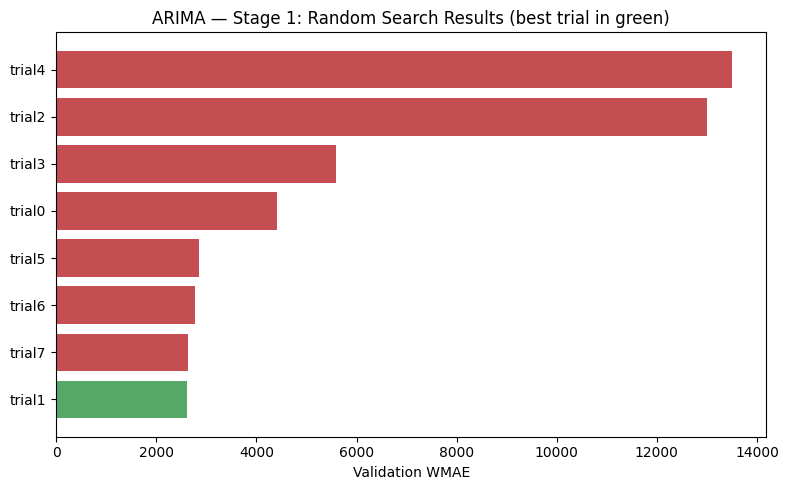

In [22]:
plot_df = results_df.sort_values("val_WMAE")
colors = ["#55A868" if t == best_row["trial"] else "#C44E52" for t in plot_df["trial"]]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(plot_df["trial"], plot_df["val_WMAE"], color=colors)
ax.set_xlabel("Validation WMAE")
ax.set_title("ARIMA — Stage 1: Random Search Results (best trial in green)")
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/arima_hp_search1_results.png", dpi=150)
plt.show()

run = wandb.init(project=WANDB_PROJECT, group=MODEL_NAME, job_type="visualization",
                  name=f"{MODEL_NAME}_Viz_StageSearch1", reinit=True)
wandb.log({"hp_search1_results": wandb.Image(f"{FIGURES_DIR}/arima_hp_search1_results.png")})
run.finish()

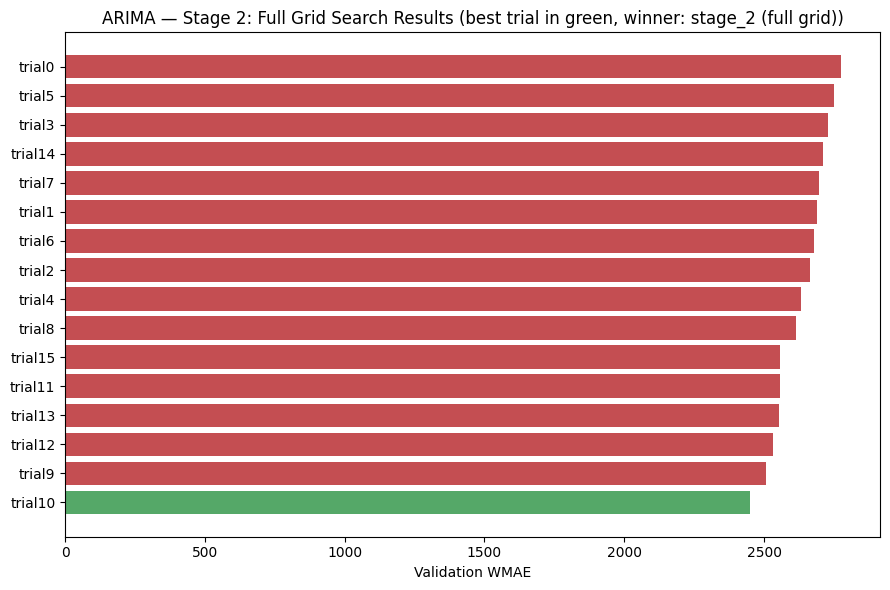

In [23]:
plot_df2 = results_2_df.sort_values("val_WMAE")
colors2 = ["#55A868" if t == best_row_2["trial"] else "#C44E52" for t in plot_df2["trial"]]
fig, ax = plt.subplots(figsize=(9, max(6, 0.3 * len(plot_df2))))
ax.barh(plot_df2["trial"], plot_df2["val_WMAE"], color=colors2)
ax.set_xlabel("Validation WMAE")
ax.set_title(f"ARIMA — Stage 2: Full Grid Search Results (best trial in green, winner: {winning_stage})")
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/arima_hp_search2_results.png", dpi=150)
plt.show()

run = wandb.init(project=WANDB_PROJECT, group=MODEL_NAME, job_type="visualization",
                  name=f"{MODEL_NAME}_Viz_StageSearch2", reinit=True)
wandb.log({"hp_search2_results": wandb.Image(f"{FIGURES_DIR}/arima_hp_search2_results.png")})
run.finish()

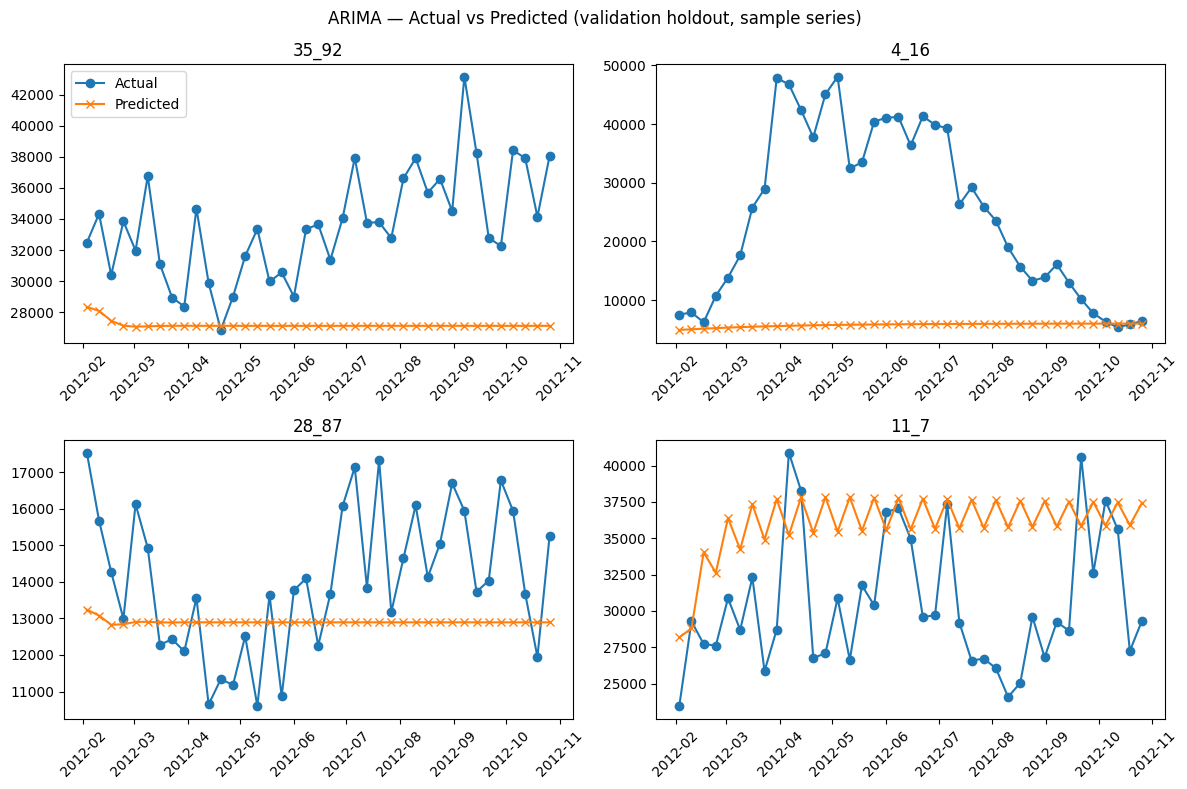

In [24]:
sample_uids = final_merged["unique_id"].drop_duplicates().sample(
    min(4, final_merged["unique_id"].nunique()), random_state=RANDOM_SEED
).tolist()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, uid in zip(axes.flat, sample_uids):
    sub = final_merged[final_merged["unique_id"] == uid].sort_values("ds")
    ax.plot(sub["ds"], sub["y"], label="Actual", marker="o")
    ax.plot(sub["ds"], sub["y_pred"], label="Predicted", marker="x")
    ax.set_title(uid)
    ax.tick_params(axis="x", rotation=45)
axes.flat[0].legend()
fig.suptitle("ARIMA — Actual vs Predicted (validation holdout, sample series)")
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/arima_actual_vs_predicted.png", dpi=150)
plt.show()

run = wandb.init(project=WANDB_PROJECT, group=MODEL_NAME, job_type="visualization",
                  name=f"{MODEL_NAME}_Viz_ActualVsPredicted", reinit=True)
wandb.log({"actual_vs_predicted": wandb.Image(f"{FIGURES_DIR}/arima_actual_vs_predicted.png")})
run.finish()

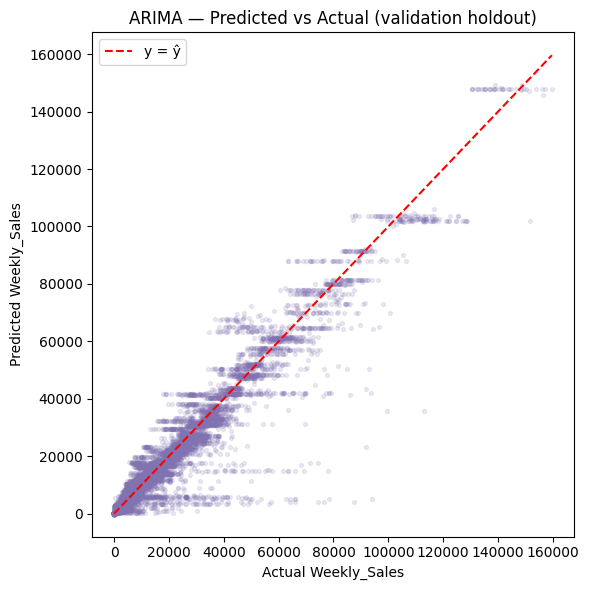

Figures saved to: /kaggle/working/arima_figures


In [25]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(final_merged["y"], final_merged["y_pred"], alpha=0.15, s=8, color="#8172B2")
lims = [0, max(final_merged["y"].max(), final_merged["y_pred"].max())]
ax.plot(lims, lims, color="red", linestyle="--", label="y = ŷ")
ax.set_xlabel("Actual Weekly_Sales")
ax.set_ylabel("Predicted Weekly_Sales")
ax.set_title("ARIMA — Predicted vs Actual (validation holdout)")
ax.legend()
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/arima_pred_vs_actual_scatter.png", dpi=150)
plt.show()

run = wandb.init(project=WANDB_PROJECT, group=MODEL_NAME, job_type="visualization",
                  name=f"{MODEL_NAME}_Viz_Scatter", reinit=True)
wandb.log({"pred_vs_actual_scatter": wandb.Image(f"{FIGURES_DIR}/arima_pred_vs_actual_scatter.png")})
run.finish()

print("Figures saved to:", os.path.abspath(FIGURES_DIR))

## 9. Full Results Summary (ტექსტური შეჯამება README-სთვის)

ყველა ეტაპის შედეგი ერთ ადგილას, ტექსტად — პირდაპირ ჩასასმელად `README.md`-ში.
ასევე ინახება `./arima_results_summary.txt` ფაილში.

In [26]:
import contextlib, io

def print_summary():
    print("=" * 70)
    print(f"{MODEL_NAME} — FULL RESULTS SUMMARY")
    print("=" * 70)

    print("\n--- 1. Data Cleaning ---")
    for k, v in train_stats.items():
        print(f"  train_{k}: {v}")
    for k, v in test_stats.items():
        print(f"  test_{k}: {v}")

    print("\n--- 2. Feature Engineering ---")
    print(f"  n_rows_train: {len(train_fe)}")
    print(f"  n_unique_series: {train_fe['unique_id'].nunique()}")

    print("\n--- 3. Feature Selection (informational, NOT used by ARIMA) ---")
    print(selection_table.to_string())

    print("\n--- 4. Train/Valid Split ---")
    print(f"  cutoff_date: {cutoff_date.date()}")
    print(f"  n_series (valid_ids): {len(valid_ids)}")
    print(f"  train rows: {len(Y_train)} | valid rows: {len(Y_valid)}")

    print("\n--- 4b. Stationarity (ADF) ---")
    print(f"  ADF p-value (level): {adf_level[1]:.4f}")
    print(f"  ADF p-value (diff, d=1): {adf_diff[1]:.4f}")

    print(f"\n--- 5. Hyperparameter Search -- Stage 1 (Random Search, {len(sample_ids)}-series sample) ---")
    print(results_df.to_string(index=False))
    print(f"\n  Stage 1 best: {best_row['trial']} | val_WMAE={best_row['val_WMAE']:.2f} | val_MAE={best_row['val_MAE']:.2f}")

    print(f"\n--- 5b. Hyperparameter Search -- Stage 2 (Full Grid Search, {len(configs_2)} trials) ---")
    print(results_2_df.to_string(index=False))
    print(f"\n  Stage 2 best: {best_row_2['trial']} | val_WMAE={best_row_2['val_WMAE']:.2f} | val_MAE={best_row_2['val_MAE']:.2f}")

    print(f"\n  WINNING STAGE: {winning_stage}")
    print(f"  FINAL best_cfg: {best_cfg} | order={final_order} | seasonal_order={final_seasonal_order}")

    print(f"\n--- 6. Final Training ({len(final_eval_ids)}-series holdout evaluation) ---")
    print(f"  final_wmae (holdout, 39-week): {final_wmae:.2f}")
    print(f"  final_mae  (holdout, 39-week): {final_mae:.2f}")
    print(f"  failed fits: {final_failed}/{len(final_eval_ids)}")

    print("\n--- 7. Deploy Refit (best_cfg, full history arima_df) ---")
    print(f"  max train date used: {deploy_max_date.date()}")
    print(f"  n_series fitted: {len(deploy_ids)} | failed: {deploy_failed}")
    print(f"  pipeline saved to: {PIPELINE_DIR}")

    print("\n--- 8. Pipeline Preview (raw test.csv -> predictions, with fallback) ---")
    print(f"  shape: {preds_preview.shape}")
    print(preds_preview.head(10).to_string(index=False))

    print("\n--- 9. Wandb Registry ---")
    print(f"  artifact name: {MODEL_NAME}_pipeline")
    print(f"  registry target: wandb-registry-model/{MODEL_NAME}")

    print("\n" + "=" * 70)
    print("END OF SUMMARY")
    print("=" * 70)

print_summary()

buf = io.StringIO()
with contextlib.redirect_stdout(buf):
    print_summary()
summary_text = buf.getvalue()
with open("./arima_results_summary.txt", "w", encoding="utf-8") as f:
    f.write(summary_text)
print(f"\nSaved to ./arima_results_summary.txt ({len(summary_text)} chars)")

ARIMA — FULL RESULTS SUMMARY

--- 1. Data Cleaning ---
  train_rows_before: 421570
  train_rows_after: 421570
  train_duplicates_removed: 0
  train_negative_sales_clipped: 1285
  train_markdown_na_filled: 1422431
  test_rows_before: 115064
  test_rows_after: 115064
  test_duplicates_removed: 0
  test_negative_sales_clipped: 0
  test_markdown_na_filled: 51493

--- 2. Feature Engineering ---
  n_rows_train: 421570
  n_unique_series: 3331

--- 3. Feature Selection (informational, NOT used by ARIMA) ---
              abs_corr_with_y  missing_rate
MarkDown5            0.050465           0.0
MarkDown1            0.047172           0.0
MarkDown3            0.038562           0.0
MarkDown4            0.037467           0.0
Unemployment         0.025860           0.0
CPI                  0.020923           0.0
MarkDown2            0.020720           0.0
Temperature          0.002312           0.0
Fuel_Price           0.000121           0.0

--- 4. Train/Valid Split ---
  cutoff_date: 2012-01-27

## შედეგი

`final_wmae` არის ის რიცხვი, რომელიც ამ notebook-იდან შედარდება NBEATS-ის, TFT-ის
და დანარჩენი არქიტექტურების `val_WMAE`-ს — ყველაზე დაბალი WMAE იგებს. ARIMA/
SARIMA-ს შემთხვევაში ეს შედარება განსაკუთრებით საინტერესოა **მეთოდოლოგიური**
თვალსაზრისით: NBEATS/TFT ერთ გლობალურ, გაზიარებული წონების მოდელს სწავლობდა
ყველა სერიაზე ერთდროულად, ხოლო ARIMA/SARIMA — **სრულიად დამოუკიდებელ** მოდელს
თითო `(Store, Dept)` წყვილზე. ეს ნიშნავს: (ა) ARIMA-ს არ შეუძლია სერიებს შორის
სტრუქტურის სესხება (მაგ. მსგავსი დეპარტამენტების ერთმანეთისგან სწავლა), რაც
ცოტა ისტორიის მქონე სერიებზე ნაკლებად ეფექტურს ხდის მას; (ბ) სამაგიეროდ
ARIMA/SARIMA უფრო **ინტერპრეტირებადია** (თითოეული კოეფიციენტის მნიშვნელობა
ცხადია) და **სტაბილურია** მაშინაც, როცა სერიას საკუთარი, სხვებისგან
დამოუკიდებელი დინამიკა აქვს; (გ) compute-ხარჯი წრფივად იზრდება სერიების
რაოდენობასთან ერთად (deep-learning მოდელებისგან განსხვავებით, სადაც compute
დამოუკიდებელია სერიების რაოდენობისგან batch-ის ფარგლებში), რაც პირდაპირ
ასახულია იმაში, რომ ამ notebook-ის HP-search სემფლი (15 სერია) და საბოლოო
შეფასების ზღვარი (`MAX_FINAL_SERIES=300`) მნიშვნელოვნად პატარაა NBEATS/
TFT-ის 150-სერიიან სემფლთან შედარებით.

საბოლოო `best_cfg` (`order`, `seasonal_order`) არჩეულია **ორსაფეხურიანი HP
search-ით** (Stage 1: random search; Stage 2: სრული ფაქტორული grid search
დინამიურად დაზუსტებულ `d`/`seasonal` კანდიდატებზე), წინ უძღოდა ADF/ACF/PACF
სტაციონარულობის დიაგნოსტიკა, რომელმაც უშუალოდ ხელმძღვანელობდა საძიებო
სივრცის არჩევანს. `ARIMAPipeline` (deployment-ზე refit-ული per-series
`SARIMAXResults`-ებით, **fallback**-ით უცნობი/ჩავარდნილი სერიებისთვის)
დარეგისტრირებულია Wandb Registry-ში და მზადაა raw test set-ზე submission-ის
დასაგენერირებლად. `./arima_figures/`-ში შენახული 6 PNG (ლოკალურად **და**
wandb-ზე, `wandb.Image`-ით) და `./arima_results_summary.txt` README.md-ში
ჩასასმელად მზადაა.